# **DRAMA FINDER & RECOMMENDATION SYSTEM**

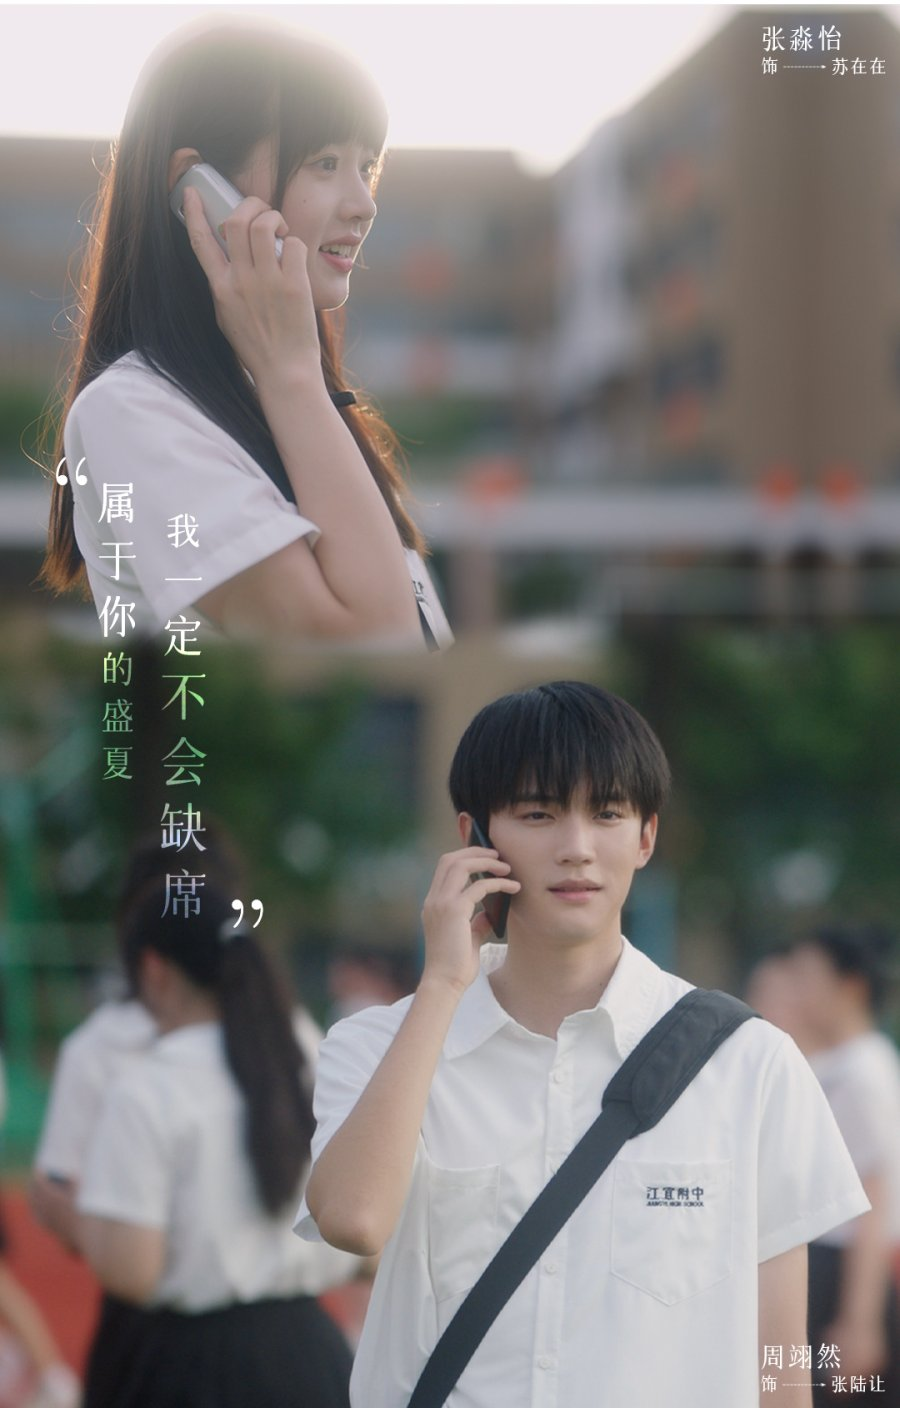

In [1]:
import pandas as pd
import kagglehub
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# **1. Load Dataset**

In [2]:
path = kagglehub.dataset_download(
    "anittasaju/complete-5000-dramas-from-mydramalist-review-info"
)

files = os.listdir(path)
csv_file = [f for f in files if f.endswith(".csv")][0]
file_path = os.path.join(path, csv_file)

df = pd.read_csv(file_path)

100%|██████████| 3.26M/3.26M [00:00<00:00, 102MB/s]

Extracting files...


In [3]:
df.head()

,Unnamed: 0,name,content,no_of_reviews,no_of_viewers,aka_names,screenwriter,director,genres,tags,...,main_role,support_role,no_of_extracted_reviews,Total_sentences,POSITIVE_people_sentiment,POSITIVE_sentences,NEGATIVE_people_sentiment,NEGATIVE_sentences,reviewer_location_info,reviewer_gender_info
0,0,goblin,Kim Shin was once an unbeatable general in Gor...,464.0,198650.0,"쓸쓸하고 찬란하神-도깨비 , Dokkaebi , Sseulsseulhago Chal...",Kim Eun Sook,Lee Eung Bok,"Comedy, Romance, Fantasy, Melodrama","Supernatural, Older Man/Younger Woman, Intersp...",...,"Gong Yoo, Kim Go Eun, Lee Dong Wook, Yoo In Na...","Lee El, Kim Sung Kyum, Kim Byung Chul, Jo Woo...",422,6390,grim reaper - (sunny; bromance; shin; relation...,3226.0,"age gap - (lead; issue), grim reaper - (sunny)...",1331.0,"Counter({'': 238, 'usa': 14, 'united states': ...","Counter({'female': 318, '': 59, 'male': 44})"
1,1,strong woman do bong soon,"Do Bong Soon is a petite, unemployed woman who...",345.0,184710.0,"Himsseonyeoja Dobongsun , Powerful Woman Do Bo...",Baek Mi Kyung,Lee Hyung Min,"Action, Comedy, Romance, Supernatural","Strong Female Lead, Female Lead Action Scenes,...",...,"Park Bo Young, Park Hyung Sik, Kim Ji Soo","Jun Suk Ho, Shim Hye Jin, Yoo Jae Myung, Ahn W...",317,4615,female lead - (male; badass; amazing; characte...,2236.0,"serial killer - (plot; gangster), female lead,...",1235.0,"Counter({'': 197, 'united states': 10, 'usa': ...","Counter({'female': 228, '': 57, 'male': 32})"
2,2,weightlifting fairy kim bok joo,Bok Joo is a weightlifter who is pursuing her ...,267.0,167702.0,"Weightlifting Fairy Kim Bok-ju , Weightlifting...","Yang Hee Seung, Kim Soo Jin","Oh Hyun Jong, Nam Sung Woo","Comedy, Romance, Life, Sports","Friends To Lovers, Weightlifting, Strong Femal...",...,"Lee Sung Kyung, Nam Joo Hyuk, Lee Jae Yoon, Ky...","Cho Hye Jung, Lee Joo Young, Ji Il Joo, Yoo J...",246,3819,"love story - (character; beautiful), female le...",2139.0,"watch drama, female lead, male lead, character...",741.0,"Counter({'': 134, 'usa': 9, 'india': 4, 'phili...","Counter({'female': 176, '': 44, 'male': 26})"
3,3,descendants of the sun,A love story that develops between a surgeon a...,270.0,167287.0,"Taeyangeui Huye , The Sun's Descendants , Taey...","Kim Eun Sook, Kim Won Seok","Baek Sang Hoon, Lee Eung Bok","Action, Comedy, Romance, Melodrama","Hardworking Male Lead, Multiple Couples, Broma...",...,"Song Joong Ki, Song Hye Kyo, Jin Goo, Kim Ji Won","Lee Seung Joon, Seo Jung Yeon, Park Hwan Hee, ...",252,3728,"watch drama - (start; want; recommend), second...",1797.0,"watch drama - (time), female lead, last episod...",816.0,"Counter({'': 143, 'india': 8, 'usa': 6, 'unite...","Counter({'female': 193, '': 35, 'male': 24})"
4,4,w,"Oh Sung Moo, the father of cardiothoracic surg...",285.0,159860.0,"W – Two Worlds , W-두 개의 세계 , W – Two Worlds Apart",Song Jae Jung,Jeong Dae Yun,"Thriller, Comedy, Romance, Fantasy","Parallel Dimension, Gun Violence, Crossworlds ...",...,"Han Hyo Joo, Lee Jong Suk","Kim Eui Sung, Lee Tae Hwan, Jung Eugene, Lee S...",265,4664,"watch drama - (recommend), love story, really ...",1925.0,"second half - (drama), watch drama - (never), ...",1167.0,"Counter({'': 151, 'usa': 7, 'india': 6, 'phili...","Counter({'female': 196, '': 48, 'male': 21})"


In [5]:
df.columns

Index(['Unnamed: 0', 'name', 'content', 'no_of_reviews', 'no_of_viewers',
       'aka_names', 'screenwriter', 'director', 'genres', 'tags', 'country',
       'type_of_show', 'episodes', 'end_date', 'start_date', 'year',
       'duration', 'rating', 'no_of_rating', 'rank', 'popularity',
       'content_rating', 'where_to_watch', 'main_role', 'support_role',
       'no_of_extracted_reviews', 'Total_sentences',
       'POSITIVE_people_sentiment', 'POSITIVE_sentences',
       'NEGATIVE_people_sentiment', 'NEGATIVE_sentences',
       'reviewer_location_info', 'reviewer_gender_info'],
      dtype='object')

In [6]:
df.describe()

,Unnamed: 0,no_of_reviews,no_of_viewers,episodes,year,rating,no_of_rating,rank,popularity,no_of_extracted_reviews,Total_sentences,POSITIVE_sentences,NEGATIVE_sentences
count,5000.000000,4985.000000,4985.000000,4985.000000,4982.000000,4985.000000,4985.000000,4985.000000,4985.000000,5000.000000,5000.000000,4814.000000,4814.000000
mean,2499.500000,24.532598,8927.782347,20.586760,2016.778001,7.655807,3938.363490,6680.361685,3409.833501,22.777400,373.634000,166.847320,99.217491
std,1443.520003,46.351016,16189.678225,20.222919,5.050646,0.508135,8422.952605,13006.839337,2186.134811,42.756949,737.447093,342.072105,191.828765
min,0.000000,0.000000,898.000000,1.000000,1971.000000,5.000000,3.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1249.750000,4.000000,1570.000000,10.000000,2014.000000,7.400000,497.000000,2209.000000,1453.000000,3.000000,42.750000,19.250000,11.000000
50%,2499.500000,8.000000,3244.000000,16.000000,2018.000000,7.700000,1110.000000,4248.000000,3261.000000,7.000000,113.000000,50.000000,30.000000
75%,3749.250000,24.000000,8596.000000,24.000000,2021.000000,8.000000,3296.000000,6634.000000,5282.000000,22.000000,360.000000,151.000000,100.000000
max,4999.000000,741.000000,198650.000000,297.000000,2023.000000,9.200000,106102.000000,85425.000000,7445.000000,680.000000,11524.000000,5841.000000,2610.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 5000 non-null   int64  
 1   name                       5000 non-null   object 
 2   content                    4985 non-null   object 
 3   no_of_reviews              4985 non-null   float64
 4   no_of_viewers              4985 non-null   float64
 5   aka_names                  4742 non-null   object 
 6   screenwriter               3520 non-null   object 
 7   director                   3897 non-null   object 
 8   genres                     4985 non-null   object 
 9   tags                       4936 non-null   object 
 10  country                    4985 non-null   object 
 11  type_of_show               4985 non-null   object 
 12  episodes                   4985 non-null   float64
 13  end_date                   4502 non-null   objec

# **2. Select Relevant Columns**

In [8]:
df = df[[
    'name', 'genres', 'tags',
    'main_role', 'support_role',
    'content', 'country', 'rating'
]].dropna()

# Rename column
df = df.rename(columns={'name': 'title'})

In [9]:
df.head()

,title,genres,tags,main_role,support_role,content,country,rating
0,goblin,"Comedy, Romance, Fantasy, Melodrama","Supernatural, Older Man/Younger Woman, Intersp...","Gong Yoo, Kim Go Eun, Lee Dong Wook, Yoo In Na...","Lee El, Kim Sung Kyum, Kim Byung Chul, Jo Woo...",Kim Shin was once an unbeatable general in Gor...,South Korea,8.8
1,strong woman do bong soon,"Action, Comedy, Romance, Supernatural","Strong Female Lead, Female Lead Action Scenes,...","Park Bo Young, Park Hyung Sik, Kim Ji Soo","Jun Suk Ho, Shim Hye Jin, Yoo Jae Myung, Ahn W...","Do Bong Soon is a petite, unemployed woman who...",South Korea,8.7
2,weightlifting fairy kim bok joo,"Comedy, Romance, Life, Sports","Friends To Lovers, Weightlifting, Strong Femal...","Lee Sung Kyung, Nam Joo Hyuk, Lee Jae Yoon, Ky...","Cho Hye Jung, Lee Joo Young, Ji Il Joo, Yoo J...",Bok Joo is a weightlifter who is pursuing her ...,South Korea,8.8
3,descendants of the sun,"Action, Comedy, Romance, Melodrama","Hardworking Male Lead, Multiple Couples, Broma...","Song Joong Ki, Song Hye Kyo, Jin Goo, Kim Ji Won","Lee Seung Joon, Seo Jung Yeon, Park Hwan Hee, ...",A love story that develops between a surgeon a...,South Korea,8.6
4,w,"Thriller, Comedy, Romance, Fantasy","Parallel Dimension, Gun Violence, Crossworlds ...","Han Hyo Joo, Lee Jong Suk","Kim Eui Sung, Lee Tae Hwan, Jung Eugene, Lee S...","Oh Sung Moo, the father of cardiothoracic surg...",South Korea,8.5


In [10]:
df.columns

Index(['title', 'genres', 'tags', 'main_role', 'support_role', 'content',
       'country', 'rating'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4740 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         4740 non-null   object 
 1   genres        4740 non-null   object 
 2   tags          4740 non-null   object 
 3   main_role     4740 non-null   object 
 4   support_role  4740 non-null   object 
 5   content       4740 non-null   object 
 6   country       4740 non-null   object 
 7   rating        4740 non-null   float64
dtypes: float64(1), object(7)
memory usage: 333.3+ KB


In [12]:
df.describe()

,rating
count,4740.000000
mean,7.672089
std,0.498565
min,5.000000
25%,7.400000
50%,7.700000
75%,8.000000
max,9.200000


# **3. Clean & Preprocess**

In [13]:
text_cols = ['genres', 'tags', 'main_role', 'support_role', 'content', 'country']

for col in text_cols:
    df[col] = df[col].astype(str).str.lower()

# Combine features
df['combined'] = (
    df['genres'] + " " +
    df['tags'] + " " +
    df['main_role'] + " " +
    df['support_role'] + " " +
    df['content'] + " " +
    df['country']
)

# **4. Reduce Dataset Size (Optional but recommended)**

In [14]:
df = df.sample(3000, random_state=42).reset_index(drop=True)

# **5. TF-IDF Vectorization**

In [15]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

tfidf_matrix = tfidf.fit_transform(df['combined'])

In [18]:
tfidf_matrix.shape

(3000, 5000)

# **6. Similarity Matrix**

In [19]:
similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)

# **7. Recommendation Function**

In [20]:
def recommend(title, n=5):
    if title not in df['title'].values:
        return "Drama not found"

    idx = df[df['title'] == title].index[0]
    scores = list(enumerate(similarity[idx]))

    # Sort by similarity score
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]

    recommendations = df.iloc[[i[0] for i in scores]][
        ['title', 'genres', 'rating', 'country']
    ]

    return recommendations

# **8. Search Function**

In [21]:
def search(genre=None, min_rating=None, country=None):
    result = df.copy()

    if genre:
        result = result[result['genres'].str.contains(genre.lower())]

    if min_rating:
        result = result[result['rating'] >= min_rating]

    if country:
        result = result[result['country'].str.contains(country.lower())]

    return result[['title', 'genres', 'country', 'rating']].head(20)

# **9. Example Usage**

In [24]:
print("Recommendations:\n")
recommend("strong woman do bong soon")

Recommendations:



,title,genres,rating,country
603,queen of housewives,"romance, youth",7.2,south korea
2617,all about eve,"romance, life, drama, melodrama",7.6,south korea
1050,i really really like you,"food, comedy, romance, drama",7.3,south korea
814,rebel: thief who stole the people,"action, thriller, historical, romance",8.5,south korea
1480,"the great king, sejong",historical,7.8,south korea


In [25]:
print("Search Results:\n")
search("romance", 8.0, "korea")

Search Results:



,title,genres,country,rating
9,call it love,"romance, drama, melodrama",south korea,8.4
18,secret garden,"comedy, romance, melodrama, supernatural",south korea,8.2
45,misty,"thriller, mystery, romance, melodrama",south korea,8.3
56,five enough,"comedy, romance, drama, melodrama",south korea,8.3
94,18 again,"romance, life, drama, fantasy",south korea,8.7
109,thirty but seventeen,"music, mystery, comedy, romance",south korea,8.5
131,drama special season 12: a moment of romance,"comedy, romance, drama",south korea,8.0
133,her private life,"business, comedy, romance, drama",south korea,8.4
178,doom at your service,"comedy, romance, drama, fantasy",south korea,8.4
198,love to hate you,"comedy, law, romance",south korea,8.6
